GPU is available


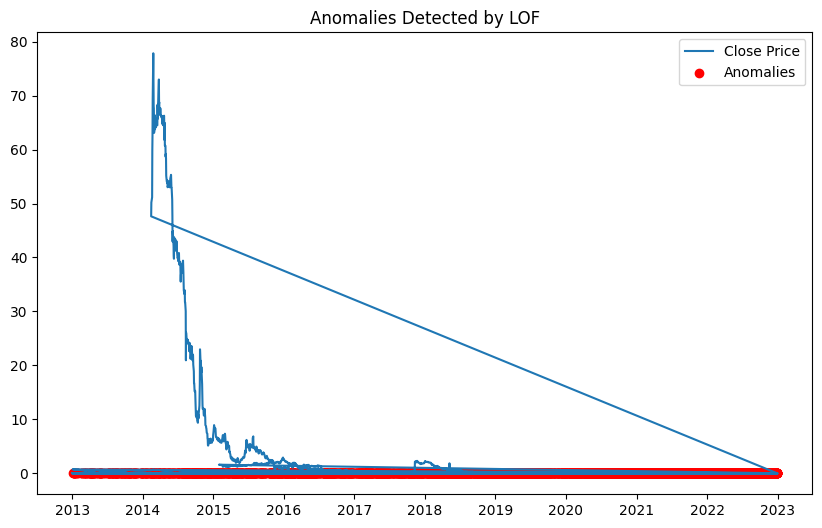

Epoch 1/100


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  96/9905 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.3028

W0000 00:00:1723971923.900758     107 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


9905/9905 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0445 - val_loss: 2.5016
Epoch 2/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0059 - val_loss: 2.5016
Epoch 3/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0057 - val_loss: 2.5016
Epoch 4/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0059 - val_loss: 2.5016
Epoch 5/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0059 - val_loss: 2.5016
Epoch 6/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.0060 - val_loss: 2.5016
Epoch 7/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0060 - val_loss: 2.5016
Epoch 8/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0059 - val_loss: 2.5016
Epoch 9/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.0059 - val_loss: 2.5016
Epoch 10/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.0058 - val_loss: 2.5016
Epoch 11/100
9905/9905 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.0059 - val_loss: 2.5016
Epoch 12/100
9905/99

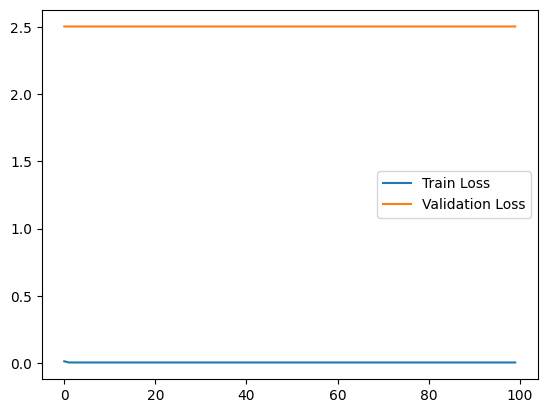

12382/12382 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step


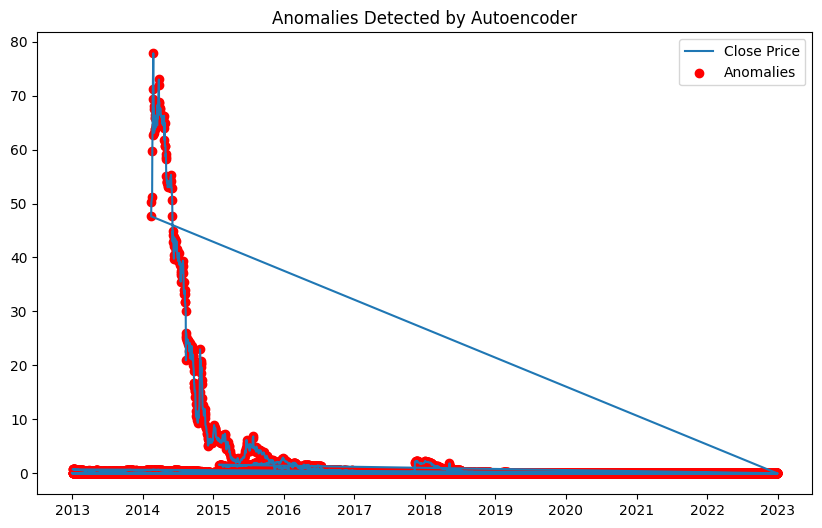

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Dropout, Conv1D, MaxPooling1D, Flatten, Input, Reshape, UpSampling1D
import matplotlib.pyplot as plt

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("GPU is available")
else:
    print("GPU is not available")

# Load the data from the CSV file
file_path = "/kaggle/input/sharvary-data-for-masters-thesis-2-1/Sharvary data for masters thesis 2 (1).csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)

# Select the 'Close' prices for anomaly detection
prices = data[['Close']]

# Normalize the data using StandardScaler
scaler = StandardScaler()
prices_scaled = scaler.fit_transform(prices)

# Convert the scaled data back to a DataFrame
prices_scaled = pd.DataFrame(prices_scaled, index=prices.index, columns=['Close'])

# Apply Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
prices_scaled['Anomaly'] = lof.fit_predict(prices_scaled[['Close']])

# Filter anomalies
anomalies_lof = prices_scaled[prices_scaled['Anomaly'] == -1]

# Plot the results
plt.figure(figsize=(10,6))
plt.plot(prices_scaled.index, prices_scaled['Close'], label='Close Price')
plt.scatter(anomalies_lof.index, anomalies_lof['Close'], color='red', label='Anomalies')
plt.title('Anomalies Detected by LOF')
plt.legend()
plt.show()

# Build an Autoencoder model
input_dim = prices_scaled.shape[1]
encoding_dim = 14

autoencoder = Sequential([
    Dense(encoding_dim, activation="relu", input_shape=(input_dim,)),
    Dense(int(encoding_dim / 2), activation="relu"),
    Dense(int(encoding_dim / 2), activation="relu"),
    Dense(encoding_dim, activation="relu"),
    Dense(input_dim, activation="sigmoid")
])

autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder with increased batch size
history = autoencoder.fit(prices_scaled, prices_scaled, epochs=100, batch_size=32, validation_split=0.2, shuffle=True)

# Plot the training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

# Predict and calculate reconstruction error
predictions = autoencoder.predict(prices_scaled)
mse = np.mean(np.power(prices_scaled - predictions, 2), axis=1)
threshold = np.percentile(mse, 95)

prices_scaled['Reconstruction_Error'] = mse
prices_scaled['Anomaly'] = prices_scaled['Reconstruction_Error'] > threshold

# Filter anomalies
anomalies_ae = prices_scaled[prices_scaled['Anomaly']]

# Plot the results
plt.figure(figsize=(10,6))
plt.plot(prices_scaled.index, prices_scaled['Close'], label='Close Price')
plt.scatter(anomalies_ae.index, anomalies_ae['Close'], color='red', label='Anomalies')
plt.title('Anomalies Detected by Autoencoder')
plt.legend()
plt.show()


In [ ]:
# Convert combined_data and labels to float32
combined_data = combined_data.astype(np.float32)
labels = labels.astype(np.float32)


In [ ]:
from tensorflow.keras.layers import LeakyReLU

# Define the Generator model
def build_generator(latent_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(prices_scaled.shape[1], activation='sigmoid'))
    return model

# Define the Discriminator model
def build_discriminator(input_dim):
    model = Sequential()
    model.add(Dense(512, input_dim=input_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(128))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(1, activation='sigmoid'))
    return model


In [ ]:
from tensorflow.keras.optimizers import Adam

# Set the latent dimension for the GAN
latent_dim = 100

# Build and compile the Generator and Discriminator models
generator = build_generator(latent_dim)
discriminator = build_discriminator(prices_scaled.shape[1])

# Compile the Discriminator
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy', metrics=['accuracy'])

# Make the Discriminator non-trainable when training the GAN
discriminator.trainable = False

# Build and compile the GAN model
gan_input = Input(shape=(latent_dim,))
generated_data = generator(gan_input)
gan_output = discriminator(generated_data)
gan = Model(gan_input, gan_output)
gan.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')


In [ ]:
# Training the GAN
epochs = 1000  # Number of epochs
batch_size = 64  # Batch size
latent_dim = 100  # Latent dimension for the Generator

for epoch in range(epochs):
    # Generate fake data
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    generated_data = generator.predict(noise)

    # Select a random batch of real data
    real_data = prices_scaled.sample(batch_size).values

    # Combine real and fake data
    combined_data = np.concatenate([real_data, generated_data])

    # Create labels for real (1) and fake (0) data
    labels_real = np.ones((batch_size, 1))  # Label for real data
    labels_fake = np.zeros((batch_size, 1))  # Label for fake data
    labels = np.concatenate([labels_real, labels_fake])

    # Shuffle the combined data and labels
    indices = np.arange(2 * batch_size)
    np.random.shuffle(indices)
    combined_data = combined_data[indices].astype(np.float32)
    labels = labels[indices].astype(np.float32)

    # Train the Discriminator
    d_loss = discriminator.train_on_batch(combined_data, labels)

    # Train the Generator (note that we don't train the Discriminator at this step)
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    valid_y = np.ones((batch_size, 1)).astype(np.float32)  # We want the generator to fool the discriminator
    g_loss = gan.train_on_batch(noise, valid_y)

    # Print the progress
    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss[0]} | D accuracy: {100 * d_loss[1]}] [G loss: {g_loss}]")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
0 [D loss: 0.7031175494194031 | D accuracy: 50.0] [G loss: [array(0.70311755, dtype=float32), array(0.70311755, dtype=float32), array(0.5, dtype=float32)]]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


W0000 00:00:1723974345.439579     107 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━

  134/12382 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step    

W0000 00:00:1723974698.351751     108 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


12382/12382 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step


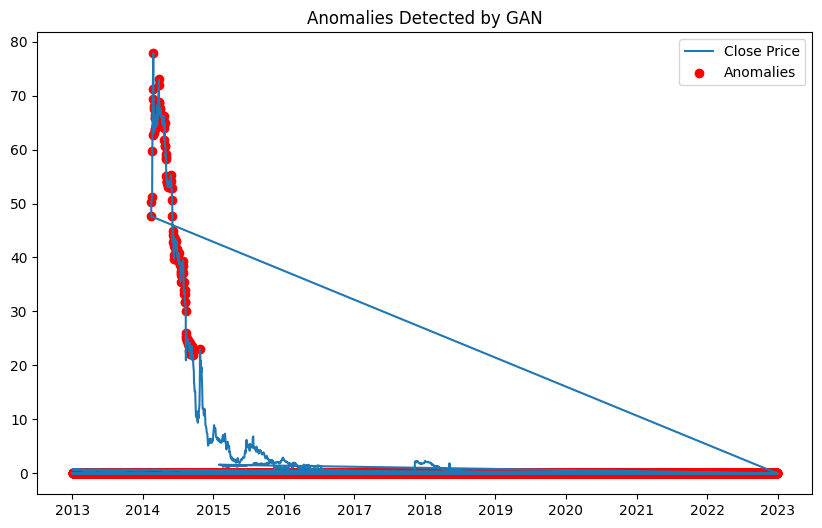

In [ ]:
# Generate the Discriminator scores for the real data
discriminator_scores = discriminator.predict(prices_scaled)

# Define a threshold for anomaly detection (you can adjust this)
threshold = np.percentile(discriminator_scores, 5)

# Identify anomalies
anomalies_gan = discriminator_scores < threshold

# Plot the results
plt.figure(figsize=(10,6))
plt.plot(prices_scaled.index, prices_scaled['Close'], label='Close Price')
plt.scatter(prices_scaled.index[anomalies_gan.flatten()], prices_scaled['Close'][anomalies_gan.flatten()], color='red', label='Anomalies')
plt.title('Anomalies Detected by GAN')
plt.legend()
plt.show()
